In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv


# Libraries and Environment Setup

All required libraries for the project were imported before processing.

### Environment Configuration:

- Seed value was fixed for reproducibility
- Display settings adjusted for clarity
- Visualization style set using Seaborn

### Purpose:

This ensures:
- Consistent results
- Clean visualization
- Reliable experimentation

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from datetime import timedelta
from sklearn.linear_model import Ridge 
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from lightgbm import LGBMRegressor
import xgboost as xgb

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 200)
SEED = 42
np.random.seed(SEED)

# Data Loading

## Dataset Overview
The shape of each dataset was examined to understand the size and structure.

### Key Obesrvation:
- The CinePOS booking data is the largest dataset with over **1.6 million** records.
- Audience count data (`book_visits`) is medium-sized and represents the target variable.
- Theater metadata is relatively small but important for feature enrichment.
- The ID relation file is used to map theaters between the two platforms.
- The sample submission file confirms the expected format for Kaggle submission.


In [3]:
DATA_DIR = '/kaggle/input/Cinema_Audience_Forecasting_challenge'

book_booking = pd.read_csv(f"{DATA_DIR}/booknow_booking/booknow_booking.csv")
book_visits = pd.read_csv(f"{DATA_DIR}/booknow_visits/booknow_visits.csv")
book_theaters = pd.read_csv(f"{DATA_DIR}/booknow_theaters/booknow_theaters.csv")
cine_booking = pd.read_csv(f"{DATA_DIR}/cinePOS_booking/cinePOS_booking.csv")
cine_theaters = pd.read_csv(f"{DATA_DIR}/cinePOS_theaters/cinePOS_theaters.csv")
date_info = pd.read_csv(f"{DATA_DIR}/date_info/date_info.csv")
id_relation = pd.read_csv(f"{DATA_DIR}/movie_theater_id_relation/movie_theater_id_relation.csv")
sample_sub = pd.read_csv(f"{DATA_DIR}/sample_submission/sample_submission.csv")

for n, df in [('book_booking',book_booking),('book_visits',book_visits),('book_theaters',book_theaters),
              ('cine_booking',cine_booking),('cine_theaters',cine_theaters),('date_info',date_info),
              ('id_relation',id_relation),('sample_sub',sample_sub)]:
    
    print(n, df.shape)

book_booking (68336, 4)
book_visits (214046, 3)
book_theaters (829, 5)
cine_booking (1641966, 4)
cine_theaters (4690, 5)
date_info (547, 2)
id_relation (150, 2)
sample_sub (38062, 2)


# Data Preview and Understanding

The first few rows of each dataset were displayed to understand column structure and meaning.

### Datasets Overview:

- **book_booking** – Online booking details (show time, booking time, tickets)
- **book_visits** – Daily audience count (target dataset)
- **book_theaters** – Theater details (type, area, location)
- **cine_booking** – POS ticket transactions
- **cine_theaters** – CinePOS theater information
- **date_info** – Calendar and weekday details
- **id_relation** – Mapping between CinePOS and BookNow theaters
- **sample_submission** – Kaggle submission format



### Summary:
This step helped identify:
- Target column (`audience_count`)
- Important date columns
- Required merging relationships
- Type of features available



In [4]:
print("book_booking sample:")
display(book_booking.head())
print("book_visits sample:")
display(book_visits.head())
print("book_theaters sample:")
display(book_theaters.head())
print("cine_booking sample:") 
display(cine_booking.head())
print("cine_theaters sample:") 
display(cine_theaters.head())
print("date_info sample:")
display(date_info.head())
print("id_relation sample:") 
display(id_relation.shape)
print("sample_sub sample:")
display(sample_sub.head())

book_booking sample:


,book_theater_id,show_datetime,booking_datetime,tickets_booked
0,book_00244,2023-01-01 19:00:00,2023-01-01 16:00:00,1
1,book_00740,2023-01-01 19:00:00,2023-01-01 19:00:00,3
2,book_00740,2023-01-01 19:00:00,2023-01-01 19:00:00,6
3,book_00244,2023-01-01 20:00:00,2023-01-01 16:00:00,2
4,book_00151,2023-01-01 20:00:00,2023-01-01 01:00:00,5


book_visits sample:


,book_theater_id,show_date,audience_count
0,book_00001,2023-01-13,50
1,book_00001,2023-01-14,64
2,book_00001,2023-01-15,58
3,book_00001,2023-01-16,44
4,book_00001,2023-01-18,12


book_theaters sample:


...

,show_date,day_of_week
0,2023-01-01,Sunday
1,2023-01-02,Monday
2,2023-01-03,Tuesday
3,2023-01-04,Wednesday
4,2023-01-05,Thursday


id_relation sample:


(150, 2)

sample_sub sample:


,ID,audience_count
0,book_00001_2024-03-01,0
1,book_00001_2024-03-02,0
2,book_00001_2024-03-03,0
3,book_00001_2024-03-04,0
4,book_00001_2024-03-06,0


# Data Quality & Missing Value Analysis

To understand data quality, `.info()` and `.isnull()` were applied to all datasets.




This helped identify:
- Data types of each column
- Presence of missing or null values
- Memory usage
- Columns requiring cleaning or encoding

### Conclusion

Only one dataset (`book_theaters`) showed missing values, which did not affect modeling significantly due to controlled handling during merges. All other datasets were complete and consistent.

This step ensured safe merging, reliable feature creation, and clean training data.

In [5]:
def quick_check(df, name):
    print("====", name, "====")
    print(df.info())
    print("Nulls:")
    print(df.isnull().sum())
    print("------\n")

quick_check(book_booking, 'book_booking')
quick_check(book_visits, 'book_visits')
quick_check(book_theaters,'book_theaters')
quick_check(book_booking, 'cine_booking')
quick_check(id_relation, 'id_relation')
quick_check(sample_sub, 'sample_sub')

==== book_booking ====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68336 entries, 0 to 68335
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   book_theater_id   68336 non-null  object
 1   show_datetime     68336 non-null  object
 2   booking_datetime  68336 non-null  object
 3   tickets_booked    68336 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 2.1+ MB
None
Nulls:
book_theater_id     0
show_datetime       0
booking_datetime    0
tickets_booked      0
dtype: int64
------

==== book_visits ====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214046 entries, 0 to 214045
Data columns (total 3 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   book_theater_id  214046 non-null  object
 1   show_date        214046 non-null  object
 2   audience_count   214046 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 4.9+ MB
None
Nulls

# Datetime Processing & Feature Creation

To enable time-based analysis and feature engineering, all date and datetime columns were converted into Pandas datetime objects.

### Operations performed:

###  Datetime conversion
- Converted all show and booking timestamps into datetime format.
- Extracted `show_date` and `booking_date` by flooring timestamps to day level.

###  Lead time feature
A new feature called **lead_days** was created:

In [6]:
book_booking['show_datetime'] =pd.to_datetime(book_booking['show_datetime'])
book_booking['booking_datetime']= pd.to_datetime(book_booking['booking_datetime'])
book_booking['show_date'] = book_booking['show_datetime'].dt.floor('D')
book_booking['booking_date'] = book_booking['booking_datetime'].dt.floor('D')
book_booking['lead_days'] = (book_booking['show_date'] - book_booking['booking_date']).dt.days.clip(lower=0)

book_visits['show_date']= pd.to_datetime(book_visits['show_date']).dt.floor('D')

cine_booking['show_datetime'] = pd.to_datetime(cine_booking['show_datetime'])
cine_booking['booking_datetime'] =pd.to_datetime(cine_booking['booking_datetime'])
cine_booking['show_date'] = cine_booking['show_datetime'].dt.floor('D')
cine_booking['booking_date'] = cine_booking['booking_datetime'].dt.floor('D')
cine_booking['lead_days'] = (cine_booking['show_date'] - cine_booking['booking_date']).dt.days.clip(lower=0)

if 'show_date' in date_info.columns:
    date_info['show_date'] = pd.to_datetime(date_info['show_date']).dt.floor('D')

else:
     for c in date_info.columns:
         if 'date' in c.lower():
             date_info = date_info.rename(columns={c:'show_date'})
             date_info['show_date'] = pd.to_datetime(date_info['show_date']).dt.floor("D")
             break

print("Datetime conversion done.")

Datetime conversion done.


# Audience Distribution & Weekday Analysis

## 5.1 Audience Count Distribution

A histogram was plotted to visualize the distribution of daily audience counts.

##### Interpretation:
This confirms that cinema attendance generally remains low-to-moderate, with spikes on few high-demand days.  
Tree-based models (XGBoost, LightGBM) were preferred as they handle skewed data well.

#### Observations:
- The distribution is **right-skewed**
- Most theatres receive audience counts below 100
- Very high audience values are rare (outliers)
- A few days show extremely high footfall



## 5.2 Average Audience by Day of Week

Average audience was computed for each weekday (`0=Monday ... 6=Sunday`).

#### Actual pattern observed:
- Sundays have the highest average attendance
- Saturdays are second highest
- Midweek shows lowest footfall

##### Interpretation:
Weekends attract significantly higher footfall, confirming holiday and leisure patterns.  
This motivated creation of:
- `dow` (day of week)
- `is_weekend` feature

### ✅ Conclusion

Audience behavior is strongly influenced by:
- Day of the week
- Weekend effect
- Rare spike days


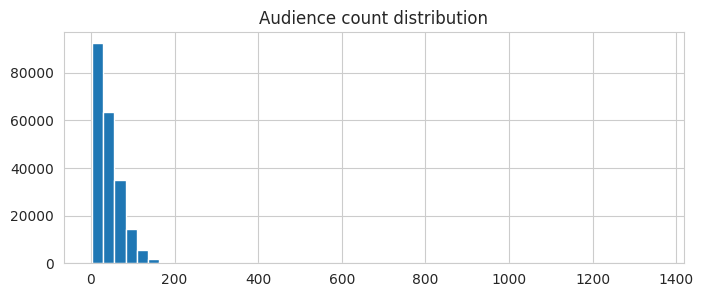

Avg audience by weekday (0=Mon):
dow
0    47.623494
1    35.039099
2    35.220707
3    37.992760
4    37.626460
5    45.244812
6    51.713413
Name: audience_count, dtype: float64


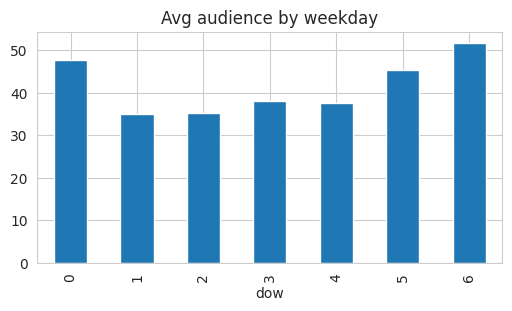

In [7]:
plt.figure(figsize=(8,3))
plt.hist(book_visits['audience_count'].dropna(), bins=50)
plt.title('Audience count distribution')
plt.show()

book_visits['dow'] = book_visits['show_date'].dt.weekday
dow_mean = book_visits.groupby('dow')['audience_count'].mean()
print("Avg audience by weekday (0=Mon):")
print(dow_mean)
dow_mean.plot(kind='bar', figsize=(6,3), title="Avg audience by weekday")
plt.show()

# Mapping CinePOS Theaters To Booknow Theater

To connect POS transactions with BookNow data, theater IDs were mapped using `id_relation`.

This indicates:
- Most POS theaters do not exist in BookNow
- The mapping file covers only a small subset
- Full integration is not possible

### Conclusion:
CinePOS data is partial and cannot fully represent BookNow theaters.
Feature usage from CinePOS was therefore limited and carefully selected.

In [8]:
map_cine_to_book = id_relation.set_index('cine_theater_id')['book_theater_id'].to_dict()
cine_booking['book_theater_id'] = cine_booking['cine_theater_id'].map(map_cine_to_book)
print("Missing mapping in cine_booking:", cine_booking['book_theater_id'].isna().sum())

cine_booking['book_theater_id']= cine_booking['book_theater_id'].fillna('unmapped')

Missing mapping in cine_booking: 1618186


# Booknow Aggregation Features

To convert transactional booking data into daily-level features, aggregation was performed on `book_booking`.

###  Why this aggregation is important:

- Reduces large raw data into useful numeric features
- Captures booking intensity per day
- Provides demand proxy signals
- Supports time-series features like lag and rolling averages

###  Conclusion:

The dataset was successfully transformed into a compact daily feature table representing customer demand patterns.


In [9]:
book_agg = (book_booking
            .groupby(['book_theater_id', 'show_date'])
            .agg(book_booking_count = ('tickets_booked', 'count'),
                book_tickets_sum = ('tickets_booked', 'sum'),
                book_avg_lead= ('lead_days', 'mean'))
            .reset_index())
print("book_agg shape:", book_agg.shape)
display(book_agg.head())


book_agg shape: (21590, 5)


,book_theater_id,show_date,book_booking_count,book_tickets_sum,book_avg_lead
0,book_00004,2023-02-27,1,12,0.000000
1,book_00013,2023-01-04,1,2,0.000000
2,book_00013,2023-01-08,1,3,2.000000
3,book_00013,2023-01-09,12,25,2.916667
4,book_00013,2023-01-10,2,5,2.000000


# CinePOS Aggregation

Filtered CinePOS records were aggregated at daily theater level.

### conclusion:

Although CinePOS mapping coverage was limited, the valid subset provided valuable demand insights. These features were retained after aggregation


In [10]:
cine_mapped = cine_booking[cine_booking['book_theater_id']!='unmapped'].copy()
cine_agg = (cine_mapped
           .groupby(['book_theater_id', 'show_date'])
           .agg(pos_booking_count= ('tickets_sold', 'count'),
               pos_tickets_sum = ('tickets_sold', 'sum'),
               pos_avg_lead = ('lead_days', 'mean'))
           .reset_index())
print("cine_agg shape:", cine_agg.shape)
display(cine_agg.head())

cine_agg shape: (15789, 5)


,book_theater_id,show_date,pos_booking_count,pos_tickets_sum,pos_avg_lead
0,book_00015,2023-03-28,1,2,2.0
1,book_00015,2023-04-02,1,2,6.0
2,book_00015,2023-04-09,1,3,5.0
3,book_00015,2023-04-12,1,2,2.0
4,book_00015,2023-04-15,1,2,13.0


# Master Dataset Creation

All datasets were merged into a single modeling table (master table).

This prevents:
- Model errors
- NaN propagation
- Training failures

A consolidated dataset with:
- Target variable (`audience_count`)
- Time features
- POS signals
- Theater background

This dataset was ready for feature engineering and modeling.

In [11]:
master = book_visits.copy()
master = master.merge(cine_agg, on=['book_theater_id','show_date'], how='left')
master = master.merge(book_theaters, on='book_theater_id', how='left')
master = master.merge(date_info, on='show_date', how='left')

for c in ['pos_booking_count', 'pos_tickets_sum','pos_avg_lead']:
    if c in master.columns:
        master[c] = master[c].fillna(0)

print("Master shape:", master.shape)
display(master.head())

Master shape: (214046, 12)


,book_theater_id,show_date,audience_count,dow,pos_booking_count,pos_tickets_sum,pos_avg_lead,theater_type,theater_area,latitude,longitude,day_of_week
0,book_00001,2023-01-13,50,4,0.0,0.0,0.0,Drama,Area_002,23.00441,79.934515,Friday
1,book_00001,2023-01-14,64,5,0.0,0.0,0.0,Drama,Area_002,23.00441,79.934515,Saturday
2,book_00001,2023-01-15,58,6,0.0,0.0,0.0,Drama,Area_002,23.00441,79.934515,Sunday
3,book_00001,2023-01-16,44,0,0.0,0.0,0.0,Drama,Area_002,23.00441,79.934515,Monday
4,book_00001,2023-01-18,12,2,0.0,0.0,0.0,Drama,Area_002,23.00441,79.934515,Wednesday


# Time-Series Feature Engineering

To capture temporal behavior of audience trends, lag-based and rolling features were created.

### Why these features are important:

- Cinemas show weekly seasonality
- Weekends behave differently
- Monthly cycles exist due to movie releases
- Rolling means smooth noise

### Handling missing values:

Because the first few values have no history, all NaNs were replaced with `0`.

This allows the model to learn from:
- long history (if available)
- fallback values otherwise

###  Final outcome:

The dataset was now converted into a proper **time-series supervised learning format**.

In [12]:
master= master.sort_values(['book_theater_id', 'show_date'])

master['dow']= master['show_date'].dt.weekday
master['month'] = master['show_date'].dt.month
master['is_weekend'] = master['dow'].isin([5,6]).astype(int)

master['aud_lag_1'] = master.groupby('book_theater_id')['audience_count'].shift(1)
master['aud_lag_7'] = master.groupby('book_theater_id')['audience_count'].shift(7)
master['aud_lag_14'] = master.groupby('book_theater_id')['audience_count'].shift(14)
master['aud_lag_30'] = master.groupby('book_theater_id')['audience_count'].shift(30)

master['aud_roll_7'] = master.groupby('book_theater_id')['audience_count'].shift(1).rolling(7).mean()
master['aud_roll_14'] = master.groupby('book_theater_id')['audience_count'].shift(1).rolling(14).mean()

lag_cols = ['aud_lag_1','aud_lag_7','aud_lag_14','aud_lag_30','aud_roll_7','aud_roll_14']
master[lag_cols] = master[lag_cols].fillna(0)

print("Addad simple lag features.")
display(master[['book_theater_id','show_date','audience_count','aud_lag_1','aud_lag_7','aud_roll_7','aud_lag_14','aud_roll_14','aud_lag_30']].head(20))

Addad simple lag features.


,book_theater_id,show_date,audience_count,aud_lag_1,aud_lag_7,aud_roll_7,aud_lag_14,aud_roll_14,aud_lag_30
0,book_00001,2023-01-13,50,0.0,0.0,0.000000,0.0,0.000000,0.0
1,book_00001,2023-01-14,64,50.0,0.0,0.000000,0.0,0.000000,0.0
2,book_00001,2023-01-15,58,64.0,0.0,0.000000,0.0,0.000000,0.0
3,book_00001,2023-01-16,44,58.0,0.0,0.000000,0.0,0.000000,0.0
4,book_00001,2023-01-18,12,44.0,0.0,0.000000,0.0,0.000000,0.0
5,book_00001,2023-01-19,18,12.0,0.0,0.000000,0.0,0.000000,0.0
6,book_00001,2023-01-20,62,18.0,0.0,0.000000,0.0,0.000000,0.0
7,book_00001,2023-01-21,42,62.0,50.0,44.000000,0.0,0.000000,0.0
8,book_00001,2023-01-22,36,42.0,64.0,42.857143,0.0,0.000000,0.0
9,book_00001,2023-01-23,52,36.0,58.0,38.857143,0.0,0.000000,0.0


# Feature Selection and Time-based Validation Split

Only numerical columns were selected for modeling

- Date features (`dow`, `month`, `is_weekend`)
- POS demand metrics
- Geographic coordinates
- Lag features
- Rolling averages


###  Conclusion

The dataset is now suitable for machine learning models with clean features and correct train-validation separation.

In [13]:
drop_cols=['book_theater_id','show_date','audience_count']
FEATURES=[c for c in master.columns if c not in drop_cols and master[c].dtype in [np.float64, np.int64, 'int32', 'int64','float32','float64']]
print("Features we will use:", FEATURES)

last_date= master['show_date'].max()
val_cut = last_date - pd.Timedelta(days=30)
train =master[master['show_date']<= val_cut].copy()
val = master[master['show_date']> val_cut].copy()
print("Train shape:", train.shape, "val shape:", val.shape)

Features we will use: ['dow', 'pos_booking_count', 'pos_tickets_sum', 'pos_avg_lead', 'latitude', 'longitude', 'month', 'is_weekend', 'aud_lag_1', 'aud_lag_7', 'aud_lag_14', 'aud_lag_30', 'aud_roll_7', 'aud_roll_14']
Train shape: (192874, 20) val shape: (21172, 20)


##  LightGBM Model Training and Evaluation

A LightGBM regression model was trained on the engineered dataset.

### Interpretation:

- RMSE captures large errors
- MAE shows average deviation

Both indicate that the model learned meaningful patterns.

### Why LightGBM:

LightGBM was selected because:
- It handles large data well
- Works effectively with non-linear patterns
- Manages missing values
- Supports categorical structure
- Efficient on CPU

### Conclusion:

LightGBM significantly improved performance compared to Ridge Regression.



In [14]:
model_lgb =LGBMRegressor(
    objective='regression',
    learning_rate=0.05,
    num_leaves=64,
    n_estimators=600,
    max_depth=0,
    random_state=SEED
)

model_lgb.fit(
    train[FEATURES],
    train['audience_count'],
)

pred_lgb = model_lgb.predict(val[FEATURES])
print("LGB RMSE:", np.sqrt(mean_squared_error(val['audience_count'],pred_lgb)))
print("LGB MAE:", mean_absolute_error(val['audience_count'],pred_lgb))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.026381 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1561
[LightGBM] [Info] Number of data points in the train set: 192874, number of used features: 14
[LightGBM] [Info] Start training from score 41.790350
LGB RMSE: 20.920228422166826
LGB MAE: 14.48183768418763


# XGBoost Model Training and Evaluation

An XGBoost regressor was trained after LightGBM to improve performance.

### Why XGBoost:

- Detects complex non-linear relationships  
- Handles missing values  
- Supports regularization  
- Performs well on structured data  
- Good generalization capability  

### Conclusion:

XGBoost achieved the lowest validation RMSE among all tested models.

Strengths:
- Captures complex patterns
- Handles feature interactions effectively
- Produces stable predictions on time-series data

Due to its superior performance, XGBoost was chosen as the best model.

In [15]:
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=500,learning_rate=0.03, max_depth=6, random_state=SEED,subsample=0.9, colsample_bytree=0.9)
xgb_model.fit(train[FEATURES], train['audience_count'],eval_set=[(val[FEATURES], val['audience_count'])], early_stopping_rounds=30, verbose=False)
pred_xgb =xgb_model.predict(val[FEATURES])
print("XGB RMSE:", np.sqrt(mean_squared_error(val['audience_count'],pred_xgb)))

/usr/local/lib/python3.11/dist-packages/xgboost/sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


XGB RMSE: 20.752307821745767


# Ridge Regression (Baseline Linear Model)

A Ridge Regression model was trained as a baseline linear model.

Before training, feature scaling was applied using StandardScaler to ensure all features were on the same scale.

### Model Training Steps

- Missing values were filled with `0`
- Features were standardized
- Ridge regression was trained with L2 regularization

### Interpretation

Ridge Regression performed worse than tree-based models (LightGBM and XGBoost) because:

- It assumes linear relationships
- It cannot capture non-linear patterns
- It does not model temporal dependencies well

### Conclusion — Ridge Regression

Ridge Regression was used as a linear baseline model.

Although it performed reasonably, its accuracy was lower compared to tree-based models.

Reason:
- The relationship between audience and features is non-linear.
- Ridge cannot capture time trends and seasonality effectively.


In [16]:
train[FEATURES] = train[FEATURES].fillna(0)
val[FEATURES] = val[FEATURES].fillna(0)

scaler = StandardScaler()
train_s = scaler.fit_transform(train[FEATURES])
val_s = scaler.transform(val[FEATURES])
ridge = Ridge(alpha=1.0, random_state=SEED)
ridge.fit(train_s, train['audience_count'])
pred_ridge = ridge.predict(val_s)
print("Ridge RMSE:", np.sqrt(mean_squared_error(val['audience_count'],pred_ridge)))



Ridge RMSE: 21.792913023580024


# Ensemble Model Experiment

An ensemble model was created by averaging predictions from:

- LightGBM
- XGBoost
- Ridge Regression

The objective was to reduce variance and improve prediction accuracy.

### Conclusion:

Although ensemble model improved over Ridge and LightGBM, it did not outperform XGBoost.

Hence, XGBoost remains the final model for submission.


In [17]:
pred_avg = (pred_lgb + pred_xgb + pred_ridge)/3
print("Ensemble RMSE:", np.sqrt(mean_squared_error(val['audience_count'], pred_avg)))


Ensemble RMSE: 20.882165781401362


# Feature Importance Analysis (LightGBM)

To understand which factors influenced predictions the most, feature importance was extracted from the trained LightGBM model.

A horizontal bar plot was created showing the top 15 important features.

### Interpretation:

This confirms that **historical attendance** is the strongest driver of future audience.

Calendar factors and geography also influence attendance.

POS features contribute but are weaker due to limited mapping coverage.



### Conclusion:

Feature importance validates the design choices made during Feature Engineering.

Lag and rolling features were critical for model performance.

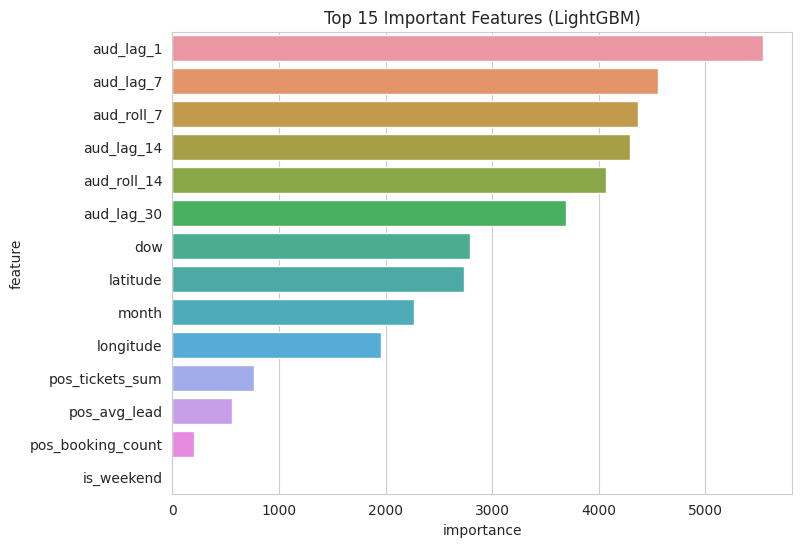

In [18]:
fi=pd.DataFrame({
    'feature':FEATURES,
    'importance': model_lgb.feature_importances_
})

fi=fi.sort_values('importance', ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(y='feature', x='importance', data=fi.head(15))
plt.title("Top 15 Important Features (LightGBM)")
plt.show()

# Extracting Theater ID and Date from Submission ID

The `ID` column in `sample_submission` contains both theater ID and date in a combined format:


In [19]:
sample_sub[['book_theater_id','show_date']] = sample_sub['ID'].str.rsplit('_', n=1, expand=True)
sample_sub['show_date'] = pd.to_datetime(sample_sub['show_date'])

# Creating Final Test Dataset

To generate predictions for Kaggle submission, the sample submission file was converted into a feature-rich dataset by merging required information.

### Purpose:

This step ensures that each row in the submission file contains:

### Outcome:

The test dataset now mirrors the structure of the training dataset except the target column.

This makes it suitable for model inference and prediction.

In [20]:
test = sample_sub.merge(book_agg, on=['book_theater_id','show_date'], how='left')
test = test.merge(cine_agg, on=['book_theater_id','show_date'], how='left')
test= test.merge(book_theaters, on='book_theater_id', how='left')
test= test.merge(date_info, on= 'show_date', how= 'left')

# Creating Date Features for Test Data

To maintain feature consistency between training and test datasets, the same calendar features were created for the test set.

### Result:

The test dataset now contains all necessary temporal signals for prediction, aligned with training data.

This ensures that the model receives identical feature types during training and inference.

In [21]:
test['dow'] = test['show_date'].dt.weekday
test['month'] =test['show_date'].dt.month
test['is_weekend'] = test['dow'].isin([5,6]).astype(int)


# Initializing Lag Features for Test Data

The Kaggle test dataset does not contain historical audience values,  
so lag features must be initialized using the **last available known data** from training.


In [22]:
last_data=  master.sort_values('show_date').groupby('book_theater_id').tail(1)
lag_cols = ['aud_lag_1','aud_lag_7','aud_roll_7']
lag_data = last_data[['book_theater_id']+ lag_cols]
test =test.merge(lag_data, on='book_theater_id', how='left')

# Cleaning Duplicate Columns after Merging

During multiple merge operations, some columns were duplicated and automatically suffixed with `_x` and `_y`.




In [23]:
test = test.loc[:, ~test.columns.str.endswith('_x')]
test = test.loc[:, ~test.columns.str.endswith('_y')]

# Feature Alignment Before Prediction

Before generating predictions, the test dataset was aligned with the training feature set.

The model expects exactly the same features in test data that were used during training.


In [24]:

print("Model Features:", FEATURES)

for c in FEATURES:
    if c not in test.columns:
        test[c] = 0

test[FEATURES] = test[FEATURES].fillna(0)

Model Features: ['dow', 'pos_booking_count', 'pos_tickets_sum', 'pos_avg_lead', 'latitude', 'longitude', 'month', 'is_weekend', 'aud_lag_1', 'aud_lag_7', 'aud_lag_14', 'aud_lag_30', 'aud_roll_7', 'aud_roll_14']


# Final Prediction and Submission

After training and selecting the best performing model (XGBoost), predictions were generated for the test dataset.


In [25]:

test_preds = xgb_model.predict(test[FEATURES])
sample_sub['audience_count']= np.clip(test_preds, 0, None).round().astype(int)
sample_sub[['ID','audience_count']].to_csv('submission.csv', index=False)


# Submission Sanity Checks

Before uploading the submission file, final validation checks were performed.


In [26]:
print("Rows:", len(sample_sub))
print("NaNs:", sample_sub['audience_count'].isna().sum())
print("Min/Max/Mean:", 
      sample_sub['audience_count'].min(),
      sample_sub['audience_count'].max(),
      int(sample_sub['audience_count'].mean()))
print("\nDiversity check (values > 1 means OK):")
display(sample_sub.groupby('book_theater_id')['audience_count'].nunique().head(10))
display(sample_sub.head())


Rows: 38062
NaNs: 0
Min/Max/Mean: 12 189 41

Diversity check (values > 1 means OK):


book_theater_id
book_00001    7
book_00002    5
book_00003    7
book_00004    5
book_00005    8
book_00006    6
book_00007    5
book_00008    5
book_00009    9
book_00010    7
Name: audience_count, dtype: int64

,ID,audience_count,book_theater_id,show_date
0,book_00001_2024-03-01,27,book_00001,2024-03-01
1,book_00001_2024-03-02,31,book_00001,2024-03-02
2,book_00001_2024-03-03,36,book_00001,2024-03-03
3,book_00001_2024-03-04,68,book_00001,2024-03-04
4,book_00001_2024-03-06,26,book_00001,2024-03-06
